# Solemne de Optimizacion: evidencia computacional con Tabu Search

Este cuaderno contiene la implementacion completa y autocontenida de la
entrega. Todas las funciones de evaluacion, la metaheuristica Tabu Search
y la generacion de figuras se integran en el mismo archivo para que la
reproduccion no dependa de modulos auxiliares externos.

##  Metodología

Aunque el enunciado original solicita una implementacion en AMPL, en esta
entrega se opto por una resolucion computacional en Python mediante Tabu
Search. La formulacion matematica se desarrolla en el informe principal y
la evidencia reproducible se conserva en este notebook ejecutado.


In [1]:
import math
import random
from io import BytesIO
from itertools import permutations, product

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

ESTACIONES = [1, 2, 3, 4]

DEMANDA = {
    1: {"R": 3000, "D": 2000},
    2: {"R": 4000, "D": 1500},
    3: {"R": 2500, "D": 3000},
    4: {"R": 1000, "D": 2500},
}

def hm(h, m=0):
    return h * 60 + m

VENTANA = {
    1: (hm(6), hm(10)),
    2: (hm(7), hm(12)),
    3: (hm(8), hm(14)),
    4: (hm(6), hm(11)),
}

CAMIONES = {
    "T1": {"C0": 8000, "C1": 7000, "fijo": 500, "salida": hm(5, 0)},
    "T2": {"C0": 6000, "C1": 9000, "fijo": 400, "salida": hm(5, 30)},
}

VELOCIDAD = 60.0
SERVICIO = 30
COSTO_KM = 2
PENAL_SHORTAGE = 10
DELTA = 0.30

DIST = {
    (0, 0): 0,  (0, 1): 20, (0, 2): 35, (0, 3): 15, (0, 4): 40,
    (1, 0): 20, (1, 1): 0,  (1, 2): 10, (1, 3): 25, (1, 4): 30,
    (2, 0): 35, (2, 1): 10, (2, 2): 0,  (2, 3): 20, (2, 4): 15,
    (3, 0): 15, (3, 1): 25, (3, 2): 20, (3, 3): 0,  (3, 4): 30,
    (4, 0): 40, (4, 1): 30, (4, 2): 15, (4, 3): 30, (4, 4): 0,
}

TASA = {"R": 500, "D": 400}
LIMPIEZA = 5

ESCENARIOS = {
    "s1_Normal": {"prob": 0.5,
        1: {"R": 3000, "D": 2000}, 2: {"R": 4000, "D": 1500},
        3: {"R": 2500, "D": 3000}, 4: {"R": 1000, "D": 2500}},
    "s2_Alta": {"prob": 0.3,
        1: {"R": 4500, "D": 2800}, 2: {"R": 5500, "D": 2000},
        3: {"R": 3500, "D": 3000}, 4: {"R": 1000, "D": 2500}},
    "s3_Baja": {"prob": 0.2,
        1: {"R": 2000, "D": 1200}, 2: {"R": 3000, "D": 1000},
        3: {"R": 1800, "D": 3000}, 4: {"R": 1000, "D": 2500}},
}

OPERACIONES_CARGA = [
    ("T1_C0", "T1", "C0", "R", 5000),
    ("T1_C1", "T1", "C1", "D", 5000),
    ("T2_C0", "T2", "C0", "D", 4000),
    ("T2_C1", "T2", "C1", "R", 3500),
]

COMBOS_COMP = [{"C0": "R", "C1": "D"}, {"C0": "D", "C1": "R"}]
COORD = {0: (0, 0), 1: (-2, 2), 2: (2.5, 1.5), 3: (-0.5, -2.2), 4: (3, -1.5)}
NOMBRE = {0: "Deposito", 1: "Est. 1", 2: "Est. 2", 3: "Est. 3", 4: "Est. 4"}
PARAM_TABU = {
    "iteraciones": 80,
    "tenencia": 7,
    "reinicios": 4,
    "semilla": 42,
    "penalizacion_inf": 100000,
}

def distancia_ruta(ruta):
    if not ruta:
        return 0
    nodos = [0] + ruta + [0]
    return sum(DIST[(nodos[i], nodos[i + 1])] for i in range(len(nodos) - 1))

def cargas_iniciales(camion, ruta, comp):
    cap = CAMIONES[camion]
    cargas = {}
    shortage = {}
    for compartimento in ("C0", "C1"):
        fuel = comp[compartimento]
        requerido = sum(DEMANDA[estacion][fuel] for estacion in ruta)
        cargado = min(requerido, cap[compartimento])
        cargas[compartimento] = cargado
        shortage[compartimento] = requerido - cargado
    return cargas, shortage

def perfil_fill_ratios(camion, ruta, comp):
    cap = CAMIONES[camion]
    cargas, _ = cargas_iniciales(camion, ruta, comp)
    restante = dict(cargas)
    perfil = [("Salida deposito", restante["C0"] / cap["C0"], restante["C1"] / cap["C1"])]
    for estacion in ruta:
        for compartimento in ("C0", "C1"):
            restante[compartimento] = max(0.0, restante[compartimento] - DEMANDA[estacion][comp[compartimento]])
        perfil.append(
            (
                f"Tras estacion {estacion}",
                restante["C0"] / cap["C0"],
                restante["C1"] / cap["C1"],
            )
        )
    return perfil

def estabilidad_ok(camion, ruta, comp):
    for _, fill_c0, fill_c1 in perfil_fill_ratios(camion, ruta, comp):
        if abs(fill_c0 - fill_c1) > DELTA + 1e-9:
            return False
    return True

def tiempos_llegada(camion, ruta):
    tiempo = CAMIONES[camion]["salida"]
    posicion = 0
    llegadas = []
    for estacion in ruta:
        tiempo += DIST[(posicion, estacion)]
        llegada = tiempo
        inicio = max(llegada, VENTANA[estacion][0])
        llegadas.append((estacion, llegada, inicio))
        tiempo = inicio + SERVICIO
        posicion = estacion
    return llegadas

def ventanas_ok(camion, ruta, estricto=False):
    for estacion, llegada, _ in tiempos_llegada(camion, ruta):
        apertura, cierre = VENTANA[estacion]
        if llegada > cierre:
            return False
        if estricto and llegada < apertura:
            return False
    return True

def evaluar(sol, estricto_ventanas=False):
    dist_total = 0
    costo_fijo = 0
    shortage_total = 0
    factible = True
    detalles = {}
    estaciones_cubiertas = []
    for camion, info in sol.items():
        ruta = info["ruta"]
        comp = info["comp"]
        estaciones_cubiertas += ruta
        dist = distancia_ruta(ruta)
        dist_total += dist
        if ruta:
            costo_fijo += CAMIONES[camion]["fijo"]
        _, shortage = cargas_iniciales(camion, ruta, comp)
        shortage_camion = sum(shortage.values())
        shortage_total += shortage_camion
        est_ok = estabilidad_ok(camion, ruta, comp) if ruta else True
        ven_ok = ventanas_ok(camion, ruta, estricto_ventanas) if ruta else True
        if (not est_ok) or (not ven_ok) or shortage_camion > 0:
            factible = False
        detalles[camion] = {
            "dist": dist,
            "estabilidad_ok": est_ok,
            "ventanas_ok": ven_ok,
            "shortage": shortage_camion,
        }
    cobertura_ok = sorted(estaciones_cubiertas) == ESTACIONES
    if not cobertura_ok:
        factible = False
    costo = COSTO_KM * dist_total + costo_fijo + PENAL_SHORTAGE * shortage_total
    return {
        "costo": costo,
        "dist_km": dist_total,
        "costo_distancia": COSTO_KM * dist_total,
        "costo_fijo": costo_fijo,
        "shortage": shortage_total,
        "factible": factible,
        "cobertura_ok": cobertura_ok,
        "detalles": detalles,
    }

def todas_las_soluciones():
    for mascara in product(["T1", "T2"], repeat=len(ESTACIONES)):
        grupos = {"T1": [], "T2": []}
        for estacion, camion in zip(ESTACIONES, mascara):
            grupos[camion].append(estacion)
        ordenes = {}
        for camion in ("T1", "T2"):
            ordenes[camion] = list(permutations(grupos[camion])) if grupos[camion] else [()]
        for ruta_t1 in ordenes["T1"]:
            for ruta_t2 in ordenes["T2"]:
                for comp_t1 in COMBOS_COMP:
                    for comp_t2 in COMBOS_COMP:
                        yield {
                            "T1": {"ruta": list(ruta_t1), "comp": dict(comp_t1)},
                            "T2": {"ruta": list(ruta_t2), "comp": dict(comp_t2)},
                        }

def optimo_fuerza_bruta(estricto_ventanas=False):
    mejor = None
    mejor_eval = None
    factibles = 0
    for sol in todas_las_soluciones():
        ev = evaluar(sol, estricto_ventanas)
        if ev["factible"]:
            factibles += 1
            if mejor_eval is None or ev["costo"] < mejor_eval["costo"]:
                mejor = sol
                mejor_eval = ev
    return mejor, mejor_eval, factibles

def tiempo_carga(litros, fuel):
    return litros / TASA[fuel] + LIMPIEZA

def calcular_tiempos_carga():
    return {op[0]: tiempo_carga(op[4], op[3]) for op in OPERACIONES_CARGA}

def scheduling_makespan():
    dur = calcular_tiempos_carga()
    inicio = {"T2_C0": 0.0, "T1_C0": 0.0}
    fin = {"T2_C0": dur["T2_C0"], "T1_C0": dur["T1_C0"]}
    inicio["T1_C1"] = max(fin["T1_C0"], fin["T2_C0"])
    fin["T1_C1"] = inicio["T1_C1"] + dur["T1_C1"]
    inicio["T2_C1"] = max(fin["T2_C0"], fin["T1_C0"])
    fin["T2_C1"] = inicio["T2_C1"] + dur["T2_C1"]
    listo = {"T1": fin["T1_C1"], "T2": fin["T2_C1"]}
    makespan = max(fin.values())
    return dur, inicio, fin, listo, makespan

def demanda_total_por_escenario():
    salida = {}
    for escenario, datos in ESCENARIOS.items():
        total_r = sum(datos[estacion]["R"] for estacion in ESTACIONES)
        total_d = sum(datos[estacion]["D"] for estacion in ESTACIONES)
        salida[escenario] = {"prob": datos["prob"], "R": total_r, "D": total_d, "total": total_r + total_d}
    return salida

def costo_penalizado(sol, penalizacion_inf=PARAM_TABU["penalizacion_inf"]):
    ev = evaluar(sol)
    costo = ev["costo"]
    if not ev["factible"]:
        costo += penalizacion_inf
    return costo, ev

def solucion_inicial():
    return {
        "T1": {"ruta": [1, 2], "comp": {"C0": "R", "C1": "D"}},
        "T2": {"ruta": [3, 4], "comp": {"C0": "R", "C1": "D"}},
    }

def solucion_aleatoria(rng):
    estaciones = list(ESTACIONES)
    rng.shuffle(estaciones)
    corte = rng.randint(0, len(estaciones))
    ruta_t1 = estaciones[:corte]
    ruta_t2 = estaciones[corte:]
    return {
        "T1": {"ruta": ruta_t1, "comp": dict(rng.choice(COMBOS_COMP))},
        "T2": {"ruta": ruta_t2, "comp": dict(rng.choice(COMBOS_COMP))},
    }

def clave(sol):
    return (
        tuple(sol["T1"]["ruta"]),
        tuple(sorted(sol["T1"]["comp"].items())),
        tuple(sol["T2"]["ruta"]),
        tuple(sorted(sol["T2"]["comp"].items())),
    )

def vecinos(sol):
    vecinos_generados = []
    rutas = {camion: list(sol[camion]["ruta"]) for camion in ("T1", "T2")}
    comp = {camion: dict(sol[camion]["comp"]) for camion in ("T1", "T2")}

    def construir(ruta_t1, ruta_t2, comp_t1, comp_t2):
        return {
            "T1": {"ruta": ruta_t1, "comp": comp_t1},
            "T2": {"ruta": ruta_t2, "comp": comp_t2},
        }

    for origen, destino in (("T1", "T2"), ("T2", "T1")):
        for estacion in rutas[origen]:
            nueva_origen = [valor for valor in rutas[origen] if valor != estacion]
            for posicion in range(len(rutas[destino]) + 1):
                nueva_destino = rutas[destino][:posicion] + [estacion] + rutas[destino][posicion:]
                nuevas_rutas = {origen: nueva_origen, destino: nueva_destino}
                vecinos_generados.append(
                    (
                        construir(
                            nuevas_rutas["T1"],
                            nuevas_rutas["T2"],
                            dict(comp["T1"]),
                            dict(comp["T2"]),
                        ),
                        f"mover {estacion}:{origen}->{destino}",
                    )
                )

    for est_t1 in rutas["T1"]:
        for est_t2 in rutas["T2"]:
            ruta_t1 = [est_t2 if valor == est_t1 else valor for valor in rutas["T1"]]
            ruta_t2 = [est_t1 if valor == est_t2 else valor for valor in rutas["T2"]]
            vecinos_generados.append(
                (
                    construir(ruta_t1, ruta_t2, dict(comp["T1"]), dict(comp["T2"])),
                    f"swap {est_t1}<->{est_t2}",
                )
            )

    for camion in ("T1", "T2"):
        ruta = rutas[camion]
        for inicio in range(len(ruta)):
            for fin in range(inicio + 1, len(ruta)):
                nueva = ruta[:inicio] + ruta[inicio:fin + 1][::-1] + ruta[fin + 1:]
                nuevas_rutas = {"T1": list(rutas["T1"]), "T2": list(rutas["T2"])}
                nuevas_rutas[camion] = nueva
                vecinos_generados.append(
                    (
                        construir(
                            nuevas_rutas["T1"],
                            nuevas_rutas["T2"],
                            dict(comp["T1"]),
                            dict(comp["T2"]),
                        ),
                        f"2opt {camion} {inicio},{fin}",
                    )
                )

    for camion in ("T1", "T2"):
        nuevas_comp = {"T1": dict(comp["T1"]), "T2": dict(comp["T2"])}
        nuevas_comp[camion] = {"C0": comp[camion]["C1"], "C1": comp[camion]["C0"]}
        vecinos_generados.append(
            (
                construir(list(rutas["T1"]), list(rutas["T2"]), nuevas_comp["T1"], nuevas_comp["T2"]),
                f"flip comp {camion}",
            )
        )

    return vecinos_generados

def tabu_search(iteraciones=80, tenencia=7, reinicios=4, semilla=42, penalizacion_inf=100000, return_meta=False):
    rng = random.Random(semilla)
    historial = []
    meta_reinicios = []
    mejor_global = None
    mejor_costo_global = None
    mejor_eval_global = None
    for reinicio in range(reinicios + 1):
        actual = solucion_inicial() if reinicio == 0 else solucion_aleatoria(rng)
        costo_actual, ev_actual = costo_penalizado(actual, penalizacion_inf)
        costo_inicial_real = ev_actual["costo"]
        factible_inicial = ev_actual["factible"]
        mejor_local = actual
        mejor_costo_local = costo_actual
        mejor_eval_local = ev_actual
        lista_tabu = {}
        if mejor_costo_global is None or costo_actual < mejor_costo_global:
            mejor_global = actual
            mejor_costo_global = costo_actual
            mejor_eval_global = ev_actual
        historial.append(mejor_costo_global)
        for iteracion in range(1, iteraciones + 1):
            mejor_vecino = None
            mejor_vecino_costo = None
            mejor_vecino_ev = None
            mejor_clave = None
            for vecino, _ in vecinos(actual):
                clave_vecino = clave(vecino)
                costo_vecino, ev_vecino = costo_penalizado(vecino, penalizacion_inf)
                es_tabu = lista_tabu.get(clave_vecino, 0) > iteracion
                aspira = mejor_costo_global is None or costo_vecino < mejor_costo_global
                if es_tabu and not aspira:
                    continue
                if mejor_vecino_costo is None or costo_vecino < mejor_vecino_costo:
                    mejor_vecino = vecino
                    mejor_vecino_costo = costo_vecino
                    mejor_vecino_ev = ev_vecino
                    mejor_clave = clave_vecino
            if mejor_vecino is None:
                break
            actual = mejor_vecino
            costo_actual = mejor_vecino_costo
            ev_actual = mejor_vecino_ev
            lista_tabu[mejor_clave] = iteracion + tenencia
            if costo_actual < mejor_costo_local:
                mejor_local = actual
                mejor_costo_local = costo_actual
                mejor_eval_local = ev_actual
            if mejor_costo_global is None or costo_actual < mejor_costo_global:
                mejor_global = actual
                mejor_costo_global = costo_actual
                mejor_eval_global = ev_actual
            historial.append(mejor_costo_global)
        meta_reinicios.append(
            {
                "reinicio": reinicio,
                "costo_inicial_real": costo_inicial_real,
                "factible_inicial": factible_inicial,
                "mejor_costo_penalizado": mejor_costo_local,
                "mejor_costo_real": mejor_eval_local["costo"],
                "factible": mejor_eval_local["factible"],
            }
        )
    if return_meta:
        meta = {
            "iteraciones": iteraciones,
            "reinicios": reinicios,
            "tenencia": tenencia,
            "semilla": semilla,
            "penalizacion_inf": penalizacion_inf,
            "arranques": meta_reinicios,
        }
        return mejor_global, mejor_eval_global, historial, meta
    return mejor_global, mejor_eval_global, historial

def png_bytes_desde_figura(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    plt.close(fig)
    return buffer.getvalue()

def imagen_desde_figura(fig):
    return Image(data=png_bytes_desde_figura(fig))

def figura_rutas(sol, titulo):
    fig, ax = plt.subplots(figsize=(6, 5))
    colores = {"T1": "#1f77b4", "T2": "#d62728"}
    for nodo, (x, y) in COORD.items():
        ax.scatter(
            [x],
            [y],
            s=600 if nodo == 0 else 420,
            c="#333333" if nodo == 0 else "#c9d6df",
            zorder=3,
            marker="s" if nodo == 0 else "o",
            edgecolors="k",
        )
        ax.annotate(
            NOMBRE[nodo],
            (x, y),
            ha="center",
            va="center",
            color="white" if nodo == 0 else "black",
            fontsize=8,
            zorder=4,
        )
    for camion in ("T1", "T2"):
        ruta = sol[camion]["ruta"]
        if not ruta:
            continue
        nodos = [0] + ruta + [0]
        for indice in range(len(nodos) - 1):
            origen, destino = nodos[indice], nodos[indice + 1]
            (x1, y1), (x2, y2) = COORD[origen], COORD[destino]
            ax.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="->",
                    color=colores[camion],
                    lw=2,
                    shrinkA=18,
                    shrinkB=18,
                ),
                zorder=2,
            )
        distancia = distancia_ruta(ruta)
        ax.plot([], [], color=colores[camion], lw=2, label=f"{camion}: D->{'->'.join(map(str, ruta))}->D ({distancia} km)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), fontsize=8)
    ax.set_title(titulo, fontsize=11, weight="bold")
    ax.axis("off")
    plt.tight_layout()
    return fig

def figura_convergencia(historial, mejor_costo):
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    ax.plot(range(len(historial)), historial, marker="o", ms=3, color="#1f77b4")
    ax.axhline(mejor_costo, ls="--", color="#2ca02c", label=f"Mejor costo = ${mejor_costo}")
    ax.set_xlabel("Iteracion acumulada")
    ax.set_ylabel("Mejor costo penalizado")
    ax.set_title("Convergencia de Tabu Search", weight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

def figura_gantt():
    duraciones, inicios, _, _, makespan = scheduling_makespan()
    fig, ax = plt.subplots(figsize=(7, 3.2))
    filas = {"Bahia Regular": ["T1_C0", "T2_C1"], "Bahia Diesel": ["T2_C0", "T1_C1"]}
    ypos = {"Bahia Regular": 1, "Bahia Diesel": 0}
    colores_op = {"T1_C0": "#1f77b4", "T1_C1": "#1f77b4", "T2_C0": "#d62728", "T2_C1": "#d62728"}
    for fila, ops in filas.items():
        for op_id in ops:
            ax.barh(
                ypos[fila],
                duraciones[op_id],
                left=inicios[op_id],
                height=0.5,
                color=colores_op[op_id],
                edgecolor="k",
                alpha=0.85,
            )
            ax.text(
                inicios[op_id] + duraciones[op_id] / 2,
                ypos[fila],
                f"{op_id}\n{duraciones[op_id]:.1f}",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
                weight="bold",
            )
    ax.axvline(makespan, ls="--", color="green")
    ax.text(makespan + 0.3, 1.35, f"Makespan = {makespan:.1f} min", color="green", fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Bahia Diesel", "Bahia Regular"])
    ax.set_xlabel("Minutos desde el inicio de la carga")
    ax.set_title("Programacion optima de carga", weight="bold")
    ax.set_xlim(0, makespan + 6)
    plt.tight_layout()
    return fig

def figura_estabilidad_t2():
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
    for ax, ruta, titulo in zip(
        axes,
        [[2, 4], [4, 2]],
        ["Ruta del operador T2: D->2->4", "Ruta reordenada T2: D->4->2"],
    ):
        perfil = perfil_fill_ratios("T2", ruta, {"C0": "D", "C1": "R"})
        etiquetas = [fila[0] for fila in perfil]
        fill_c0 = [fila[1] * 100 for fila in perfil]
        fill_c1 = [fila[2] * 100 for fila in perfil]
        x = range(len(perfil))
        ax.plot(x, fill_c0, marker="o", label="C0 (Diesel)")
        ax.plot(x, fill_c1, marker="s", label="C1 (Regular)")
        for xi, (valor_a, valor_b) in zip(x, zip(fill_c0, fill_c1)):
            diferencia = abs(valor_a - valor_b)
            ax.annotate(
                f"{diferencia:.1f}%",
                (xi, max(valor_a, valor_b) + 4),
                ha="center",
                color="red" if diferencia > 30 else "gray",
                fontsize=8,
            )
        ax.set_xticks(list(x))
        ax.set_xticklabels(etiquetas, rotation=20, fontsize=7)
        ax.set_title(titulo, fontsize=10, weight="bold")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Fill ratio (%)")
    plt.tight_layout()
    return fig

def fmt_hora(minutos):
    return f"{int(minutos // 60):02d}:{int(minutos % 60):02d}"

def ruta_texto(ruta):
    return "D->" + "->".join(map(str, ruta)) + "->D" if ruta else "No se usa"

def resumen_capacidad(sol):
    filas = []
    for camion in ("T1", "T2"):
        cargas, shortage = cargas_iniciales(camion, sol[camion]["ruta"], sol[camion]["comp"])
        for comp in ("C0", "C1"):
            fuel = sol[camion]["comp"][comp]
            requerido = sum(DEMANDA[estacion][fuel] for estacion in sol[camion]["ruta"])
            capacidad = CAMIONES[camion][comp]
            filas.append(
                {
                    "Camion": camion,
                    "Compartimento": comp,
                    "Producto": fuel,
                    "Demanda asignada (L)": requerido,
                    "Capacidad (L)": capacidad,
                    "Carga inicial (L)": cargas[comp],
                    "Shortage (L)": shortage[comp],
                    "Fill inicial": round(cargas[comp] / capacidad, 4),
                    "Cumple capacidad": requerido <= capacidad,
                }
            )
    return pd.DataFrame(filas)

def resumen_estabilidad(camion, ruta, comp):
    filas = []
    for etapa, fill_c0, fill_c1 in perfil_fill_ratios(camion, ruta, comp):
        filas.append(
            {
                "Camion": camion,
                "Etapa": etapa,
                "Fill C0": round(fill_c0, 4),
                "Fill C1": round(fill_c1, 4),
                "Diferencia": round(abs(fill_c0 - fill_c1), 4),
                "Cumple Delta": abs(fill_c0 - fill_c1) <= DELTA + 1e-9,
            }
        )
    return pd.DataFrame(filas)

def resumen_ventanas(sol):
    filas = []
    for camion in ("T1", "T2"):
        for estacion, llegada, inicio_servicio in tiempos_llegada(camion, sol[camion]["ruta"]):
            apertura, cierre = VENTANA[estacion]
            filas.append(
                {
                    "Camion": camion,
                    "Estacion": estacion,
                    "Llegada": fmt_hora(llegada),
                    "Inicio servicio": fmt_hora(inicio_servicio),
                    "Ventana": f"{fmt_hora(apertura)}-{fmt_hora(cierre)}",
                    "Espera (min)": inicio_servicio - llegada,
                    "Cumple": llegada <= cierre,
                }
            )
    return pd.DataFrame(filas)

def costo_desagregado(nombre, sol, ev):
    return {
        "Solucion": nombre,
        "Ruta T1": ruta_texto(sol["T1"]["ruta"]),
        "Ruta T2": ruta_texto(sol["T2"]["ruta"]),
        "Distancia total (km)": ev["dist_km"],
        "Costo distancia": ev["costo_distancia"],
        "Costo fijo": ev["costo_fijo"],
        "Shortage (L)": ev["shortage"],
        "Penalizacion shortage": ev["shortage"] * PENAL_SHORTAGE,
        "Costo total": ev["costo"],
        "Factible": ev["factible"],
    }

sol_operador = {
    "T1": {"ruta": [1, 3], "comp": {"C0": "R", "C1": "D"}},
    "T2": {"ruta": [2, 4], "comp": {"C0": "D", "C1": "R"}},
}
ev_operador = evaluar(sol_operador)
mejor_sol, mejor_ev, historial, meta_tabu = tabu_search(
    iteraciones=PARAM_TABU["iteraciones"],
    tenencia=PARAM_TABU["tenencia"],
    reinicios=PARAM_TABU["reinicios"],
    semilla=PARAM_TABU["semilla"],
    penalizacion_inf=PARAM_TABU["penalizacion_inf"],
    return_meta=True,
)


## 1. Datos del escenario base

Se presentan los datos del escenario determinista base: demandas por
estacion, caracteristicas de la flota y matriz de distancias utilizada en
la evaluacion del problema.


In [2]:
tabla_estaciones = pd.DataFrame(
    [
        {
            "Estacion": estacion,
            "Regular (L)": DEMANDA[estacion]["R"],
            "Diesel (L)": DEMANDA[estacion]["D"],
            "Apertura": fmt_hora(VENTANA[estacion][0]),
            "Cierre": fmt_hora(VENTANA[estacion][1]),
        }
        for estacion in ESTACIONES
    ]
)

tabla_camiones = pd.DataFrame(
    [
        {
            "Camion": camion,
            "Capacidad C0 (L)": datos["C0"],
            "Capacidad C1 (L)": datos["C1"],
            "Costo fijo": datos["fijo"],
            "Salida programada": fmt_hora(datos["salida"]),
        }
        for camion, datos in CAMIONES.items()
    ]
)

tabla_distancias = pd.DataFrame(
    [[DIST[(i, j)] for j in [0] + ESTACIONES] for i in [0] + ESTACIONES],
    index=["D"] + ESTACIONES,
    columns=["D"] + ESTACIONES,
)

display(tabla_estaciones)
display(tabla_camiones)
display(tabla_distancias)

print(
    f"Costo por kilometro = ${COSTO_KM} | Penalizacion por shortage = ${PENAL_SHORTAGE}/L | "
    f"Servicio por estacion = {SERVICIO} min | Delta de estabilidad = {DELTA:.2f}"
)


Costo por kilometro = $2 | Penalizacion por shortage = $10/L | Servicio por estacion = 30 min | Delta de estabilidad = 0.30


,Estacion,Regular (L),Diesel (L),Apertura,Cierre
0,1,3000,2000,06:00,10:00
1,2,4000,1500,07:00,12:00
2,3,2500,3000,08:00,14:00
3,4,1000,2500,06:00,11:00


,Camion,Capacidad C0 (L),Capacidad C1 (L),Costo fijo,Salida programada
0,T1,8000,7000,500,05:00
1,T2,6000,9000,400,05:30


,D,1,2,3,4
D,0,20,35,15,40
1,20,0,10,25,30
2,35,10,0,20,15
3,15,25,20,0,30
4,40,30,15,30,0


## 2. Parametros de la busqueda y criterio de evaluacion

La solucion se representa mediante una ruta ordenada por camion y una
asignacion de combustible a cada compartimento. La evaluacion combina
costo de distancia, costos fijos y penalizacion por shortage, junto con
validaciones de capacidad, estabilidad y ventanas de tiempo.


In [3]:
tabla_parametros_tabu = pd.DataFrame(
    [
        {"Parametro": "Iteraciones por arranque", "Valor": PARAM_TABU["iteraciones"]},
        {"Parametro": "Tenure tabu", "Valor": PARAM_TABU["tenencia"]},
        {"Parametro": "Reinicios adicionales", "Valor": PARAM_TABU["reinicios"]},
        {"Parametro": "Semilla", "Valor": PARAM_TABU["semilla"]},
        {"Parametro": "Penalizacion por infactibilidad", "Valor": PARAM_TABU["penalizacion_inf"]},
    ]
)

tabla_arranques = pd.DataFrame(meta_tabu["arranques"])
display(tabla_parametros_tabu)
display(tabla_arranques)


,Parametro,Valor
0,Iteraciones por arranque,80
1,Tenure tabu,7
2,Reinicios adicionales,4
3,Semilla,42
4,Penalizacion por infactibilidad,100000


,reinicio,costo_inicial_real,factible_inicial,mejor_costo_penalizado,mejor_costo_real,factible
0,0,1200,False,1130,1130,True
1,1,21160,False,1130,1130,True
2,2,45750,False,1130,1130,True
3,3,6230,False,1130,1130,True
4,4,45730,False,1130,1130,True


## 3. Analisis de la solucion propuesta por el operador

La propuesta del operador se revisa en dos planos complementarios. Primero se
contrasta la consistencia entre los fill ratios declarados y la demanda asociada
a sus rutas. Luego se evalua la misma secuencia bajo cargas corregidas para
shortage cero, con el fin de revisar capacidad, estabilidad, ventanas de tiempo
y costo operacional.


## 3.1 Consistencia entre fill ratios declarados y demanda asignada

Antes de corregir las cargas para satisfacer completamente la demanda, conviene
verificar si los fill ratios declarados por el operador son consistentes con las
rutas que afirma atender y con la declaracion de shortage igual a cero.


In [4]:
fill_ratio_declarado_operador = [
    {
        "Camion": "T1",
        "Compartimento": "C0",
        "Producto": "Regular",
        "Fill ratio declarado": "62.5%",
        "Litros declarados": 5000,
        "Litros requeridos": DEMANDA[1]["R"] + DEMANDA[3]["R"],
    },
    {
        "Camion": "T1",
        "Compartimento": "C1",
        "Producto": "Diesel",
        "Fill ratio declarado": "71.4%",
        "Litros declarados": 5000,
        "Litros requeridos": DEMANDA[1]["D"] + DEMANDA[3]["D"],
    },
    {
        "Camion": "T2",
        "Compartimento": "C0",
        "Producto": "Diesel",
        "Fill ratio declarado": "66.7%",
        "Litros declarados": 4000,
        "Litros requeridos": DEMANDA[2]["D"] + DEMANDA[4]["D"],
    },
    {
        "Camion": "T2",
        "Compartimento": "C1",
        "Producto": "Regular",
        "Fill ratio declarado": "38.9%",
        "Litros declarados": 3500,
        "Litros requeridos": DEMANDA[2]["R"] + DEMANDA[4]["R"],
    },
]

for fila in fill_ratio_declarado_operador:
    fila["Diferencia"] = fila["Litros declarados"] - fila["Litros requeridos"]
    fila["Shortage por fill declarado"] = max(0, fila["Litros requeridos"] - fila["Litros declarados"])

tabla_fill_ratio_operador = pd.DataFrame(fill_ratio_declarado_operador)
display(tabla_fill_ratio_operador)
print(
    "Shortage total por fill ratios declarados =",
    int(tabla_fill_ratio_operador["Shortage por fill declarado"].sum()),
    "L",
)


Shortage total por fill ratios declarados = 2000 L


,Camion,Compartimento,Producto,Fill ratio declarado,Litros declarados,Litros requeridos,Diferencia,Shortage por fill declarado
0,T1,C0,Regular,62.5%,5000,5500,-500,500
1,T1,C1,Diesel,71.4%,5000,5000,0,0
2,T2,C0,Diesel,66.7%,4000,4000,0,0
3,T2,C1,Regular,38.9%,3500,5000,-1500,1500


Por lo tanto, los fill ratios declarados por el operador no son
consistentes con la afirmacion de shortage igual a cero. Si se respetan esos
fill ratios, existe un faltante total de 2000 L. Por esta razon, el analisis
posterior evalua la misma secuencia de rutas bajo cargas corregidas, es decir,
cargando los litros necesarios para satisfacer toda la demanda asignada.

### 3.2 Evaluacion de la ruta del operador bajo cargas corregidas para shortage cero

A continuacion se evalua la ruta del operador bajo cargas corregidas para
satisfacer toda la demanda asignada. Bajo este supuesto, el costo operacional
total es 1200; sin embargo, la solucion sigue siendo infactible por violar la
restriccion de estabilidad en T2 despues de atender la estacion 2.


,Camion,Compartimento,Producto,Demanda asignada (L),Capacidad (L),Carga inicial (L),Shortage (L),Fill inicial,Cumple capacidad
0,T1,C0,R,5500,8000,5500,0,0.6875,True
1,T1,C1,D,5000,7000,5000,0,0.7143,True
2,T2,C0,D,4000,6000,4000,0,0.6667,True
3,T2,C1,R,5000,9000,5000,0,0.5556,True


,Camion,Etapa,Fill C0,Fill C1,Diferencia,Cumple Delta
0,T1,Salida deposito,0.6875,0.7143,0.0268,True
1,T1,Tras estacion 1,0.3125,0.4286,0.1161,True
2,T1,Tras estacion 3,0.0000,0.0000,0.0000,True
3,T2,Salida deposito,0.6667,0.5556,0.1111,True
4,T2,Tras estacion 2,0.4167,0.1111,0.3056,False
5,T2,Tras estacion 4,0.0000,0.0000,0.0000,True


,Camion,Estacion,Llegada,Inicio servicio,Ventana,Espera (min),Cumple
0,T1,1,05:20,06:00,06:00-10:00,40,True
1,T1,3,06:55,08:00,08:00-14:00,65,True
2,T2,2,06:05,07:00,07:00-12:00,55,True
3,T2,4,07:45,07:45,06:00-11:00,0,True


,Concepto,Valor
0,Distancia T1,60
1,Distancia T2,90
2,Distancia total,150
3,Costo distancia real,300
4,Costo fijo,900
5,Shortage,0
6,Costo total real,1200
7,Costo distancia declarado por el operador,260


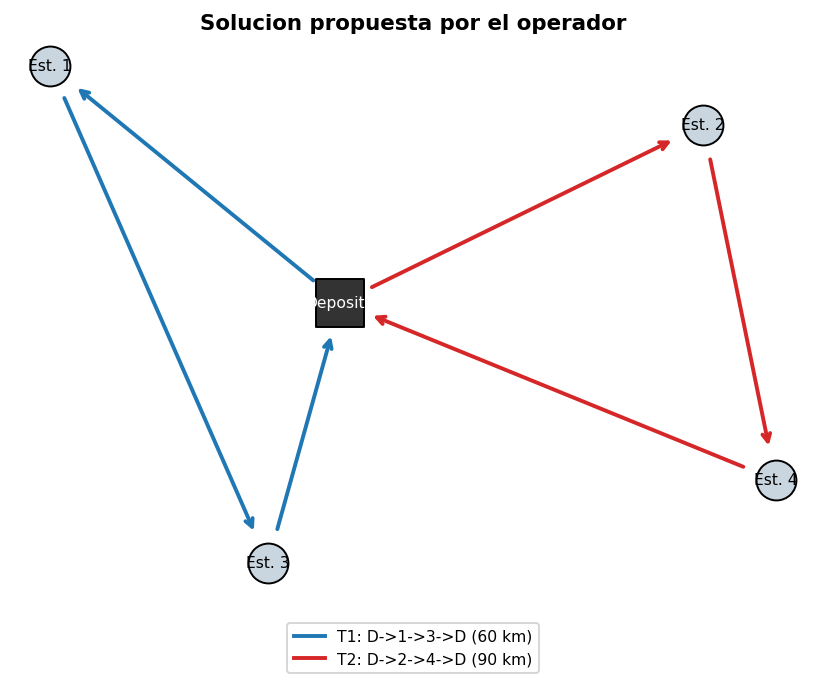

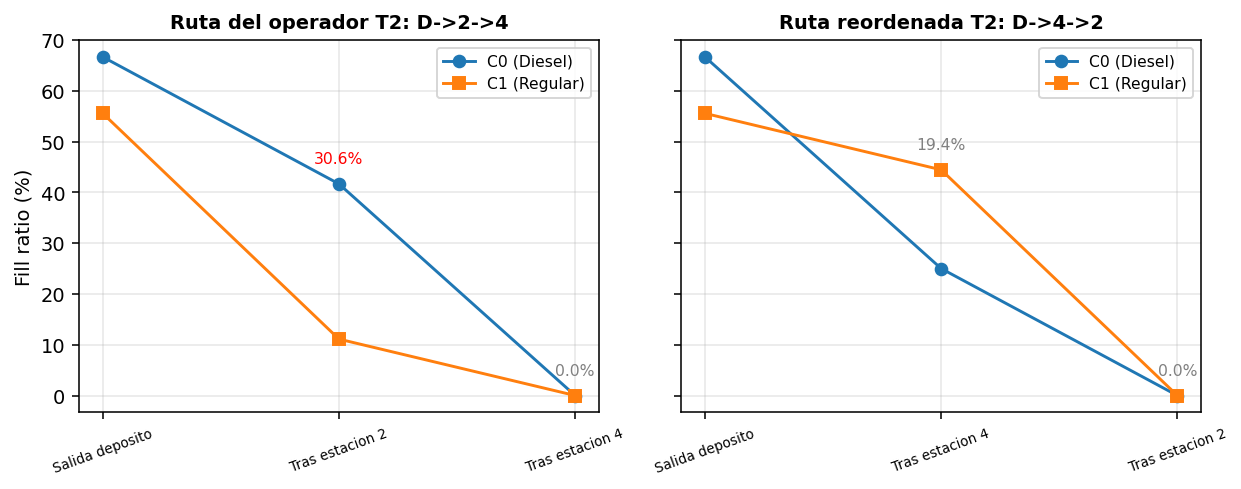

In [5]:
display(resumen_capacidad(sol_operador))

estabilidad_operador = pd.concat(
    [
        resumen_estabilidad("T1", sol_operador["T1"]["ruta"], sol_operador["T1"]["comp"]),
        resumen_estabilidad("T2", sol_operador["T2"]["ruta"], sol_operador["T2"]["comp"]),
    ],
    ignore_index=True,
)
display(estabilidad_operador)
display(resumen_ventanas(sol_operador))

tabla_costos_operador = pd.DataFrame(
    [
        {"Concepto": "Distancia T1", "Valor": distancia_ruta(sol_operador["T1"]["ruta"])},
        {"Concepto": "Distancia T2", "Valor": distancia_ruta(sol_operador["T2"]["ruta"])},
        {"Concepto": "Distancia total", "Valor": ev_operador["dist_km"]},
        {"Concepto": "Costo distancia real", "Valor": ev_operador["costo_distancia"]},
        {"Concepto": "Costo fijo", "Valor": ev_operador["costo_fijo"]},
        {"Concepto": "Shortage", "Valor": ev_operador["shortage"]},
        {"Concepto": "Costo total real", "Valor": ev_operador["costo"]},
        {"Concepto": "Costo distancia declarado por el operador", "Valor": 260},
    ]
)
display(tabla_costos_operador)

display(imagen_desde_figura(figura_rutas(sol_operador, "Solucion propuesta por el operador")))
display(imagen_desde_figura(figura_estabilidad_t2()))


## 4. Propuesta de mejora mediante Tabu Search

Se presenta la mejor solucion obtenida por la metaheuristica, junto con
la comparacion contra la propuesta del operador y las verificaciones de
factibilidad correspondientes.


,Camion,Ruta,Compartimento C0,Compartimento C1,Distancia (km)
0,T1,D->1->2->4->D,R,D,85
1,T2,D->3->D,R,D,30


,Camion,Compartimento,Producto,Demanda asignada (L),Capacidad (L),Carga inicial (L),Shortage (L),Fill inicial,Cumple capacidad
0,T1,C0,R,8000,8000,8000,0,1.0000,True
1,T1,C1,D,6000,7000,6000,0,0.8571,True
2,T2,C0,R,2500,6000,2500,0,0.4167,True
3,T2,C1,D,3000,9000,3000,0,0.3333,True


,Solucion,Ruta T1,Ruta T2,Distancia total (km),Costo distancia,Costo fijo,Shortage (L),Penalizacion shortage,Costo total,Factible
0,Operador,D->1->3->D,D->2->4->D,150,300,900,0,0,1200,False
1,Tabu Search,D->1->2->4->D,D->3->D,115,230,900,0,0,1130,True


,Camion,Etapa,Fill C0,Fill C1,Diferencia,Cumple Delta
0,T1,Salida deposito,1.0000,0.8571,0.1429,True
1,T1,Tras estacion 1,0.6250,0.5714,0.0536,True
2,T1,Tras estacion 2,0.1250,0.3571,0.2321,True
3,T1,Tras estacion 4,0.0000,0.0000,0.0000,True
4,T2,Salida deposito,0.4167,0.3333,0.0833,True
5,T2,Tras estacion 3,0.0000,0.0000,0.0000,True


,Camion,Estacion,Llegada,Inicio servicio,Ventana,Espera (min),Cumple
0,T1,1,05:20,06:00,06:00-10:00,40,True
1,T1,2,06:40,07:00,07:00-12:00,20,True
2,T1,4,07:45,07:45,06:00-11:00,0,True
3,T2,3,05:45,08:00,08:00-14:00,135,True


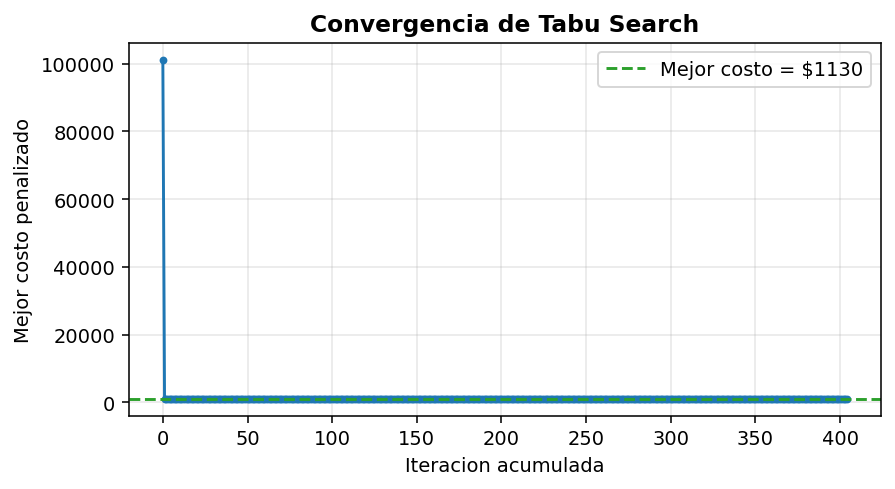

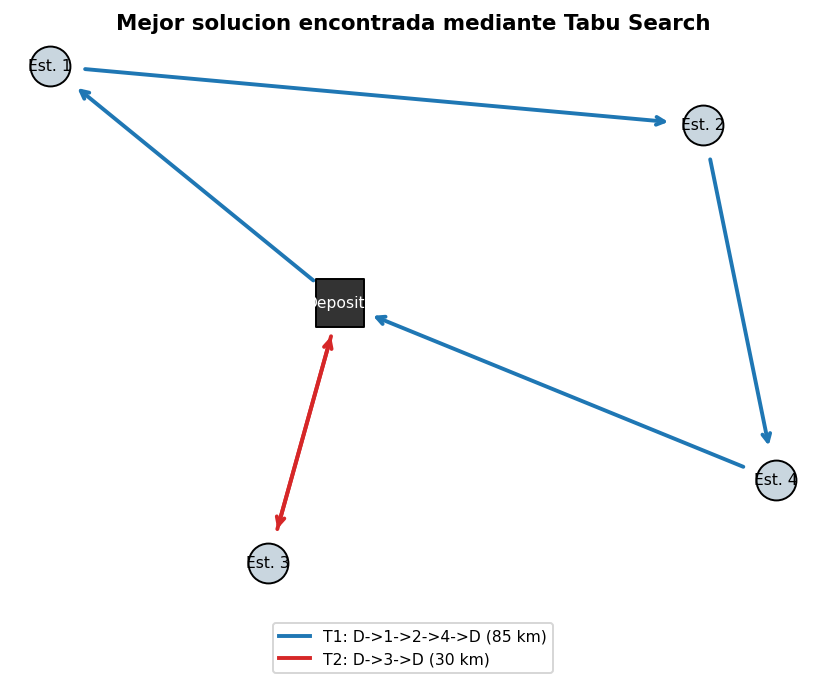

In [6]:
tabla_mejor_solucion = pd.DataFrame(
    [
        {
            "Camion": camion,
            "Ruta": ruta_texto(mejor_sol[camion]["ruta"]),
            "Compartimento C0": mejor_sol[camion]["comp"]["C0"],
            "Compartimento C1": mejor_sol[camion]["comp"]["C1"],
            "Distancia (km)": distancia_ruta(mejor_sol[camion]["ruta"]),
        }
        for camion in ("T1", "T2")
    ]
)

tabla_cargas_mejor = resumen_capacidad(mejor_sol)

comparacion = pd.DataFrame(
    [
        costo_desagregado("Operador", sol_operador, ev_operador),
        costo_desagregado("Tabu Search", mejor_sol, mejor_ev),
    ]
)

estabilidad_mejor = pd.concat(
    [
        resumen_estabilidad("T1", mejor_sol["T1"]["ruta"], mejor_sol["T1"]["comp"]),
        resumen_estabilidad("T2", mejor_sol["T2"]["ruta"], mejor_sol["T2"]["comp"]),
    ],
    ignore_index=True,
)

display(tabla_mejor_solucion)
display(tabla_cargas_mejor)
display(comparacion)
display(estabilidad_mejor)
display(resumen_ventanas(mejor_sol))

display(imagen_desde_figura(figura_convergencia(historial, mejor_ev["costo"])))
display(imagen_desde_figura(figura_rutas(mejor_sol, "Mejor solucion encontrada mediante Tabu Search")))


## 5. Validacion exhaustiva

Como la instancia tiene pocas estaciones, es posible enumerar todas las
asignaciones, ordenes de visita y configuraciones de compartimentos para
verificar si la solucion de Tabu Search coincide con el mejor costo
factible del espacio completo.


In [7]:
registros = []
for sol in todas_las_soluciones():
    ev = evaluar(sol)
    registros.append(
        {
            "Ruta T1": ruta_texto(sol["T1"]["ruta"]),
            "Ruta T2": ruta_texto(sol["T2"]["ruta"]),
            "Comp T1": f"C0={sol['T1']['comp']['C0']} / C1={sol['T1']['comp']['C1']}",
            "Comp T2": f"C0={sol['T2']['comp']['C0']} / C1={sol['T2']['comp']['C1']}",
            "Distancia (km)": ev["dist_km"],
            "Costo total": ev["costo"],
            "Factible": ev["factible"],
        }
    )

enumeracion = pd.DataFrame(registros)
factibles = enumeracion[enumeracion["Factible"]].sort_values(
    ["Costo total", "Distancia (km)", "Ruta T1", "Ruta T2"]
).reset_index(drop=True)
mejor_bruta, eval_bruta, n_factibles = optimo_fuerza_bruta()

resumen_enumeracion = pd.DataFrame(
    [
        {"Metrica": "Soluciones enumeradas", "Valor": len(enumeracion)},
        {"Metrica": "Soluciones factibles", "Valor": n_factibles},
        {"Metrica": "Mejor costo por fuerza bruta", "Valor": eval_bruta["costo"]},
        {"Metrica": "Mejor costo por Tabu Search", "Valor": mejor_ev["costo"]},
        {
            "Metrica": "Coincidencia Tabu Search vs fuerza bruta",
            "Valor": mejor_ev["costo"] == eval_bruta["costo"],
        },
    ]
)

display(resumen_enumeracion)
display(factibles.head(10))
print("Ruta optima por fuerza bruta T1:", ruta_texto(mejor_bruta["T1"]["ruta"]))
print("Ruta optima por fuerza bruta T2:", ruta_texto(mejor_bruta["T2"]["ruta"]))


Ruta optima por fuerza bruta T1: D->1->2->4->D
Ruta optima por fuerza bruta T2: D->3->D


,Metrica,Valor
0,Soluciones enumeradas,480
1,Soluciones factibles,54
2,Mejor costo por fuerza bruta,1130
3,Mejor costo por Tabu Search,1130
4,Coincidencia Tabu Search vs fuerza bruta,True


,Ruta T1,Ruta T2,Comp T1,Comp T2,Distancia (km),Costo total,Factible
0,D->1->2->4->D,D->3->D,C0=R / C1=D,C0=R / C1=D,115,1130,True
1,D->1->2->4->D,D->3->D,C0=R / C1=D,C0=D / C1=R,115,1130,True
2,D->3->D,D->4->2->1->D,C0=R / C1=D,C0=D / C1=R,115,1130,True
3,D->3->D,D->4->2->1->D,C0=D / C1=R,C0=D / C1=R,115,1130,True
4,D->1->4->2->D,D->3->D,C0=R / C1=D,C0=R / C1=D,130,1160,True
5,D->1->4->2->D,D->3->D,C0=R / C1=D,C0=D / C1=R,130,1160,True
6,D->2->4->1->D,D->3->D,C0=R / C1=D,C0=R / C1=D,130,1160,True
7,D->2->4->1->D,D->3->D,C0=R / C1=D,C0=D / C1=R,130,1160,True
8,D->3->2->4->D,D->1->D,C0=R / C1=D,C0=R / C1=D,130,1160,True
9,D->3->2->4->D,D->1->D,C0=R / C1=D,C0=D / C1=R,130,1160,True


## 6. Scheduling de carga en el deposito

Se calcula el tiempo de carga por compartimento, la secuencia optima por
bahia y la verificacion de salida de ambos camiones respecto de su horario
programado.


Makespan optimo = 32.5 minutos


,Operacion,Camion,Compartimento,Producto,Litros,Tasa (L/min),Duracion total (min),Inicio (min),Termino (min)
0,T1_C0,T1,C0,R,5000,500,15.0,0.0,15.0
1,T1_C1,T1,C1,D,5000,400,17.5,15.0,32.5
2,T2_C0,T2,C0,D,4000,400,15.0,0.0,15.0
3,T2_C1,T2,C1,R,3500,500,12.0,15.0,27.0


,Camion,Listo si la carga inicia a las 04:00,Salida programada,Cumple salida
0,T1,04:32,05:00,True
1,T2,04:27,05:30,True


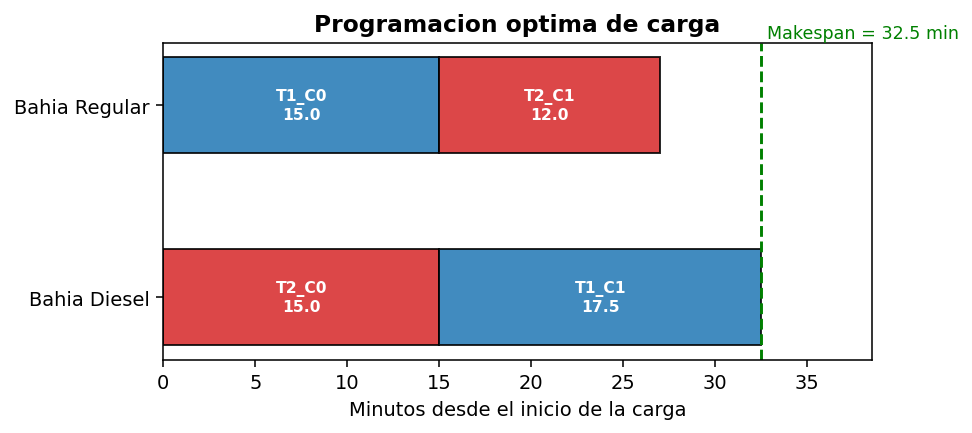

In [8]:
duraciones, inicios, terminos, listo, makespan = scheduling_makespan()

tabla_operaciones = pd.DataFrame(
    [
        {
            "Operacion": op_id,
            "Camion": camion,
            "Compartimento": compartimento,
            "Producto": fuel,
            "Litros": litros,
            "Tasa (L/min)": TASA[fuel],
            "Duracion total (min)": duraciones[op_id],
            "Inicio (min)": inicios[op_id],
            "Termino (min)": terminos[op_id],
        }
        for op_id, camion, compartimento, fuel, litros in OPERACIONES_CARGA
    ]
)

tabla_salidas = pd.DataFrame(
    [
        {
            "Camion": camion,
            "Listo si la carga inicia a las 04:00": fmt_hora(hm(4, 0) + listo[camion]),
            "Salida programada": fmt_hora(CAMIONES[camion]["salida"]),
            "Cumple salida": hm(4, 0) + listo[camion] <= CAMIONES[camion]["salida"],
        }
        for camion in ("T1", "T2")
    ]
)

display(tabla_operaciones)
display(tabla_salidas)
print(f"Makespan optimo = {makespan:.1f} minutos")
display(imagen_desde_figura(figura_gantt()))


## 7. Extension estocastica de dos etapas

Se resume la extension estocastica del problema, separando las decisiones
de primera etapa de las decisiones de segunda etapa asociadas a cada
escenario de demanda.


In [9]:
tabla_escenarios = pd.DataFrame(
    [
        {
            "Escenario": escenario,
            "Probabilidad": datos["prob"],
            "Regular total (L)": sum(datos[estacion]["R"] for estacion in ESTACIONES),
            "Diesel total (L)": sum(datos[estacion]["D"] for estacion in ESTACIONES),
            "Demanda total (L)": sum(datos[estacion]["R"] + datos[estacion]["D"] for estacion in ESTACIONES),
        }
        for escenario, datos in ESCENARIOS.items()
    ]
)

tabla_etapas = pd.DataFrame(
    [
        {
            "Etapa": "Primera etapa",
            "Decision principal": "Rutas, uso de camiones y asignacion producto-compartimento",
            "Momento": "Antes de observar la demanda",
        },
        {
            "Etapa": "Segunda etapa",
            "Decision principal": "Cargas efectivas y shortage por escenario",
            "Momento": "Despues de observar la demanda del escenario",
        },
    ]
)

resumen_capacidad_total = pd.DataFrame(
    [
        {"Concepto": "Capacidad total flota", "Valor": sum(camion["C0"] + camion["C1"] for camion in CAMIONES.values())},
        {"Concepto": "Capacidad maxima Regular", "Valor": CAMIONES["T1"]["C0"] + CAMIONES["T2"]["C1"]},
        {"Concepto": "Capacidad maxima Diesel", "Valor": CAMIONES["T1"]["C1"] + CAMIONES["T2"]["C0"]},
    ]
)

display(tabla_escenarios)
display(tabla_etapas)
display(resumen_capacidad_total)


,Escenario,Probabilidad,Regular total (L),Diesel total (L),Demanda total (L)
0,s1_Normal,0.5,10500,9000,19500
1,s2_Alta,0.3,14500,10300,24800
2,s3_Baja,0.2,7800,7700,15500


,Etapa,Decision principal,Momento
0,Primera etapa,"Rutas, uso de camiones y asignacion producto-c...",Antes de observar la demanda
1,Segunda etapa,Cargas efectivas y shortage por escenario,Despues de observar la demanda del escenario


,Concepto,Valor
0,Capacidad total flota,30000
1,Capacidad maxima Regular,17000
2,Capacidad maxima Diesel,13000


## 8. Resultados

Los resultados reproducidos en este cuaderno confirman que:

- la solucion del operador no es factible por una violacion de estabilidad;
- bajo cargas corregidas para shortage cero, el costo operacional de la
  propuesta del operador es 1200; sin embargo, los fill ratios declarados no
  son consistentes con shortage cero;
- la mejor solucion encontrada mediante Tabu Search alcanza un costo total de
  `1130`;
- el scheduling de carga presenta makespan optimo de `32.5` minutos;
- la validacion exhaustiva confirma la coincidencia entre Tabu Search y el mejor
  costo factible enumerado.
